In [1]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Load Data

In [3]:
image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness= 0.2, contrast= 0.2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean= [0.485, 0.456, 0.406], std= [0.229, 0.224, 0.225])
])

In [4]:
dataset_path = "./dataset/"

dataset = datasets.ImageFolder(root = dataset_path, transform = image_transforms)

In [5]:
class_names = dataset.classes 
class_names

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [6]:
num_classes = len(dataset.classes)
num_classes

6

In [7]:
train_size = int(0.75 * len(dataset))
val_size = len(dataset) - train_size

train_size, val_size

(1725, 575)

In [8]:
from torch.utils.data import random_split

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [9]:
train_loader = DataLoader(train_dataset, batch_size= 32, shuffle= True)
val_loader = DataLoader(val_dataset, batch_size= 32, shuffle= True)

### Model 1: CNN

In [10]:
class CarClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels= 3, out_channels= 16, kernel_size= 3, stride= 1, padding= 1), # (16, 224, 224)
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size= 2, stride= 2, padding= 0), # (16, 112, 112)
            nn.Conv2d(in_channels= 16, out_channels= 32, kernel_size= 3, stride= 1, padding= 1),
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size= 2, stride= 2, padding= 0), # (32, 56, 56)
            nn.Conv2d(in_channels= 32, out_channels= 64, kernel_size= 3, stride= 1, padding= 1),
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size= 2, stride= 2, padding= 0), # (64, 28, 28)

            nn.Flatten(),

            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.network(x)
        return x

In [11]:
# Initialise the model, loss function, and optimiser
model = CarClassifierCNN(num_classes = num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimiser = optim.Adam(model.parameters(), lr = 0.001)

In [12]:
def train_model(model, criterion, optimizer, epochs = 5):
    start = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            if (batch_num + 1) % 10 == 0:
                print(f"Batch: {batch_num + 1}, Epoch: {epoch + 1}, Loss: {loss.item():0.2f}")

            running_loss += loss.item() * images.size(0)
        
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch + 1}/ {epochs}], Avg Loss: {epoch_loss:.4f}")

        # Validation
        model.eval()
        correct = 0
        total = 0 
        all_labels = []
        all_predictions = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())  
                
            print(f"***** Validation Accuracy: {100 * correct / total:.2f}% *****")

    end = time.time()
    print(f"Execution time: {end - start} seconds")
    return all_labels, all_predictions

In [13]:
all_labels, all_predictions = train_model(model, criterion, optimiser, epochs = 3)

Batch: 10, Epoch: 1, Loss: 1.76
Batch: 20, Epoch: 1, Loss: 1.78
Batch: 30, Epoch: 1, Loss: 1.79
Batch: 40, Epoch: 1, Loss: 1.73
Batch: 50, Epoch: 1, Loss: 1.79
Epoch [1/ 3], Avg Loss: 2.1453
***** Validation Accuracy: 18.43% *****
Batch: 10, Epoch: 2, Loss: 1.74
Batch: 20, Epoch: 2, Loss: 1.73
Batch: 30, Epoch: 2, Loss: 1.84
Batch: 40, Epoch: 2, Loss: 1.74
Batch: 50, Epoch: 2, Loss: 1.82
Epoch [2/ 3], Avg Loss: 1.7708
***** Validation Accuracy: 18.43% *****
Batch: 10, Epoch: 3, Loss: 1.80
Batch: 20, Epoch: 3, Loss: 1.69
Batch: 30, Epoch: 3, Loss: 1.75
Batch: 40, Epoch: 3, Loss: 1.75
Batch: 50, Epoch: 3, Loss: 1.74
Epoch [3/ 3], Avg Loss: 1.7632
***** Validation Accuracy: 18.43% *****
Execution time: 347.15953063964844 seconds


### Model 2: CNN with Regularization

In [14]:
class CarClassifierCNNwithRegularization(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels= 3, out_channels= 16, kernel_size= 3, stride= 1, padding= 1), # (16, 224, 224)
            nn.BatchNorm2d(16),
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size= 2, stride= 2, padding= 0), # (16, 112, 112)
            nn.Conv2d(in_channels= 16, out_channels= 32, kernel_size= 3, stride= 1, padding= 1),
            nn.BatchNorm2d(32),
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size= 2, stride= 2, padding= 0), # (32, 56, 56)
            nn.Conv2d(in_channels= 32, out_channels= 64, kernel_size= 3, stride= 1, padding= 1),
            nn.BatchNorm2d(64),
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size= 2, stride= 2, padding= 0), # (64, 28, 28)

            nn.Flatten(),

            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 64),
            nn.Dropout(0.5),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.network(x)
        return x

In [15]:
model = CarClassifierCNNwithRegularization(num_classes = num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001, weight_decay= 1e-4)

all_labels, all_predictions = train_model(model, criterion, optimizer, epochs= 3)

Batch: 10, Epoch: 1, Loss: 7.44
Batch: 20, Epoch: 1, Loss: 2.33
Batch: 30, Epoch: 1, Loss: 1.79
Batch: 40, Epoch: 1, Loss: 1.79
Batch: 50, Epoch: 1, Loss: 1.79
Epoch [1/ 3], Avg Loss: 3.3115
***** Validation Accuracy: 22.61% *****
Batch: 10, Epoch: 2, Loss: 1.78
Batch: 20, Epoch: 2, Loss: 1.80
Batch: 30, Epoch: 2, Loss: 1.76
Batch: 40, Epoch: 2, Loss: 1.77
Batch: 50, Epoch: 2, Loss: 1.74
Epoch [2/ 3], Avg Loss: 1.7835
***** Validation Accuracy: 22.61% *****
Batch: 10, Epoch: 3, Loss: 1.82
Batch: 20, Epoch: 3, Loss: 1.77
Batch: 30, Epoch: 3, Loss: 1.78
Batch: 40, Epoch: 3, Loss: 1.76
Batch: 50, Epoch: 3, Loss: 1.75
Epoch [3/ 3], Avg Loss: 1.7745
***** Validation Accuracy: 22.61% *****
Execution time: 373.54459261894226 seconds


### Model 3: Transfer Learning with EfficientNet

In [16]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(weights = "DEFAULT")

        for param in self.model.parameters():
            param.requires_grad = False
        
        in_features = self.model.classifier[1].in_features

        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [17]:
model = CarClassifierEfficientNet(num_classes = num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr= 0.001)
    
all_labels, all_predictions = train_model(model, criterion, optimizer, epochs= 3)

Batch: 10, Epoch: 1, Loss: 1.81
Batch: 20, Epoch: 1, Loss: 1.54
Batch: 30, Epoch: 1, Loss: 1.38
Batch: 40, Epoch: 1, Loss: 1.48
Batch: 50, Epoch: 1, Loss: 1.22
Epoch [1/ 3], Avg Loss: 1.4873
***** Validation Accuracy: 52.70% *****
Batch: 10, Epoch: 2, Loss: 1.60
Batch: 20, Epoch: 2, Loss: 2.30
Batch: 30, Epoch: 2, Loss: 3.29
Batch: 40, Epoch: 2, Loss: 2.48
Batch: 50, Epoch: 2, Loss: 1.86
Epoch [2/ 3], Avg Loss: 2.1828
***** Validation Accuracy: 52.35% *****
Batch: 10, Epoch: 3, Loss: 2.87
Batch: 20, Epoch: 3, Loss: 4.58
Batch: 30, Epoch: 3, Loss: 5.12
Batch: 40, Epoch: 3, Loss: 2.43
Batch: 50, Epoch: 3, Loss: 3.73
Epoch [3/ 3], Avg Loss: 3.9338
***** Validation Accuracy: 43.48% *****
Execution time: 401.22866106033325 seconds


### Model 4: Transfer Learning with ResNet

In [18]:
class CarClassifierResNet(nn.Module):
    def __init__(self, num_classes, dropout_rate = 0.5):
        super().__init__()
        self.model = models.resnet50(weights = "DEFAULT")

        for param in self.model.parameters():
            param.requires_grad = False

        for param in self.model.layer4.parameters():
            param.requires_grad = True

        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features, num_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [20]:
model = CarClassifierResNet(num_classes = num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr= 0.001)
    
all_labels, all_predictions = train_model(model, criterion, optimizer, epochs= 3)

Batch: 10, Epoch: 1, Loss: 1.13
Batch: 20, Epoch: 1, Loss: 0.62
Batch: 30, Epoch: 1, Loss: 0.96
Batch: 40, Epoch: 1, Loss: 1.21
Batch: 50, Epoch: 1, Loss: 1.19
Epoch [1/ 3], Avg Loss: 1.0791
***** Validation Accuracy: 33.74% *****
Batch: 10, Epoch: 2, Loss: 1.07
Batch: 20, Epoch: 2, Loss: 1.31
Batch: 30, Epoch: 2, Loss: 0.92
Batch: 40, Epoch: 2, Loss: 1.59
Batch: 50, Epoch: 2, Loss: 0.87
Epoch [2/ 3], Avg Loss: 1.1064
***** Validation Accuracy: 57.74% *****
Batch: 10, Epoch: 3, Loss: 1.37
Batch: 20, Epoch: 3, Loss: 0.86
Batch: 30, Epoch: 3, Loss: 0.77
Batch: 40, Epoch: 3, Loss: 1.13
Batch: 50, Epoch: 3, Loss: 1.51
Epoch [3/ 3], Avg Loss: 1.0501
***** Validation Accuracy: 60.52% *****
Execution time: 719.1825833320618 seconds


<h4>Run hyperparameter tunning in another notebook and figured that the best parameters for resnet models are (1) Dropout rate = 0.2 (2) Learning Rate = 0.005</h4>

In [21]:
model = CarClassifierResNet(num_classes=num_classes, dropout_rate=0.2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.005)

labels, predictions = train_model(model, criterion, optimizer, epochs=3)

Batch: 10, Epoch: 1, Loss: 1.56
Batch: 20, Epoch: 1, Loss: 1.53
Batch: 30, Epoch: 1, Loss: 1.26
Batch: 40, Epoch: 1, Loss: 2.05
Batch: 50, Epoch: 1, Loss: 1.39
Epoch [1/ 3], Avg Loss: 1.5001
***** Validation Accuracy: 32.70% *****
Batch: 10, Epoch: 2, Loss: 0.99
Batch: 20, Epoch: 2, Loss: 1.30
Batch: 30, Epoch: 2, Loss: 1.00
Batch: 40, Epoch: 2, Loss: 0.93
Batch: 50, Epoch: 2, Loss: 0.72
Epoch [2/ 3], Avg Loss: 1.2980
***** Validation Accuracy: 57.39% *****
Batch: 10, Epoch: 3, Loss: 1.08
Batch: 20, Epoch: 3, Loss: 1.87
Batch: 30, Epoch: 3, Loss: 0.57
Batch: 40, Epoch: 3, Loss: 0.73
Batch: 50, Epoch: 3, Loss: 1.35
Epoch [3/ 3], Avg Loss: 1.6843
***** Validation Accuracy: 58.96% *****
Execution time: 718.9909734725952 seconds


### Model Evaluation using Confusion Matrix and Classification Report

In [22]:
from sklearn.metrics import classification_report

report = classification_report(labels, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.94      0.27      0.42       106
           1       0.41      0.95      0.57        87
           2       1.00      0.62      0.77       130
           3       0.65      0.45      0.53        82
           4       0.44      0.65      0.53        86
           5       0.71      0.63      0.67        84

    accuracy                           0.59       575
   macro avg       0.69      0.60      0.58       575
weighted avg       0.72      0.59      0.59       575



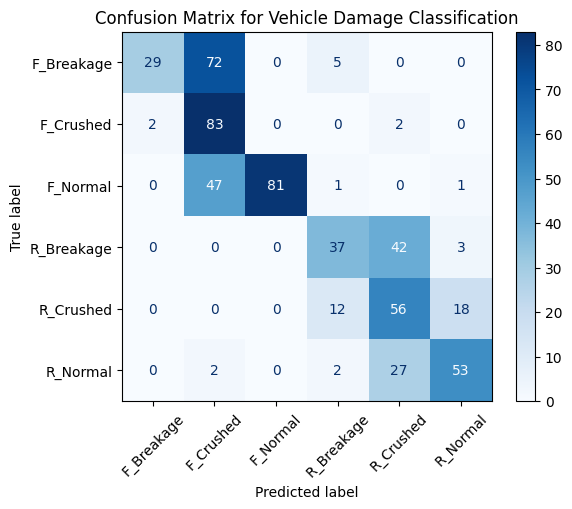

In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

### Save the Model

In [24]:
torch.save(model.state_dict(), 'saved_model.pth')